In [4]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:")
print(df["Machine failure"].value_counts())

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3    

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

Correlation with Machine failure:
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


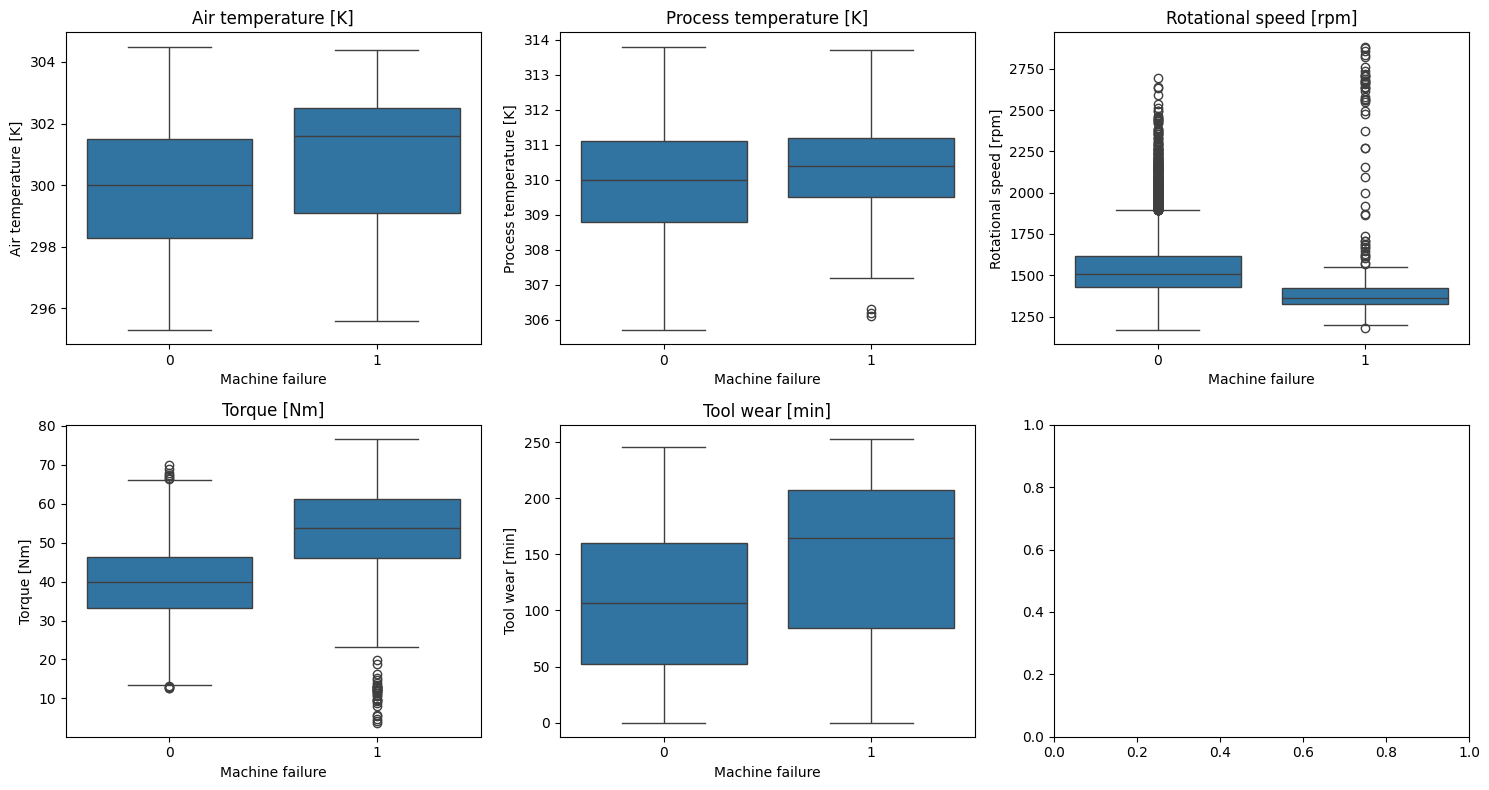

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of failure types
failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
print(df[failure_cols].sum())

# Correlation of numeric features with target
numeric_cols = ["Air temperature [K]", "Process temperature [K]", 
                 "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

corr = df[numeric_cols + ["Machine failure"]].corr()
print("\nCorrelation with Machine failure:")
print(corr["Machine failure"].sort_values(ascending=False))

# Quick boxplot to see how features differ by failure status
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(data=df, x="Machine failure", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# Features we'll use for prediction (drop IDs and failure-type breakdown columns,
# since those are diagnostic labels, not sensor inputs)
feature_cols = ["Air temperature [K]", "Process temperature [K]", 
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]", "Type"]

X = df[feature_cols].copy()
y = df["Machine failure"]

# One-hot encode 'Type' (categorical: L, M, H)
X = pd.get_dummies(X, columns=["Type"], drop_first=True)

print(X.head())
print("\nX shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train failure rate:", y_train.mean())
print("Test failure rate:", y_test.mean())

   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_L  Type_M  
0         42.8                0   False    True  
1         46.3                3    True   False  
2         49.4                5    True   False  
3         39.5                7    True   False  
4         40.0                9    True   False  

X shape: (10000, 7)

Train shape: (8000, 7) Test shape: (2000, 7)
Train failure rate: 0.033875
Test failure rate: 0.034
